In [1]:
import numpy as np
import json
import torch
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
Npoint = 8
fmin = 10
fmax = 1e5

freq = np.linspace(fmin, fmax, Npoint)
freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), Npoint)
print(f'linear: {[f"{x:.2f}" for x in freq]}')
print(f'log   : {[f"{x:.2f}" for x in freq_log]}')
print(f'manual: {[f"{x:.2f}" for x in fmin*10**np.linspace(0, np.log10(fmax/fmin), Npoint)]}')

linear: ['10.00', '14294.29', '28578.57', '42862.86', '57147.14', '71431.43', '85715.71', '100000.00']
log   : ['10.00', '37.28', '138.95', '517.95', '1930.70', '7196.86', '26826.96', '100000.00']
manual: ['10.00', '37.28', '138.95', '517.95', '1930.70', '7196.86', '26826.96', '100000.00']


In [3]:
def linear_idx_to_log_idx(positions, Npoint, fmin, fmax):
    """Map linear spacing index/indices to equivalent log spacing index/indices."""
    positions = np.asarray(positions)          # Handles scalars, lists, arrays uniformly
    R = fmax / fmin
    N = Npoint - 1
    return np.round((N * np.log10(1 + positions * (R - 1) / N) / np.log10(R))).astype(int)

# Your parameters
Npoint, fmin, fmax = 8, 10, 1e5

# Test: i=2 → j≈?
i = 2
j = linear_idx_to_log_idx(i, Npoint, fmin, fmax)
print(f"Linear idx {i} → Log idx {j:.3f}")  # Output: ~6.048

# Verify the frequencies match
freq_lin = np.linspace(fmin, fmax, Npoint)
freq_log = np.logspace(np.log10(fmin), np.log10(fmax), Npoint)
print(f"Linear freq[{i}] = {freq_lin[i]:.2f} Hz")
print(f"Log freq[{round(j)}] = {freq_log[round(j)]:.2f} Hz")

Linear idx 2 → Log idx 6.000
Linear freq[2] = 28578.57 Hz
Log freq[6] = 26826.96 Hz


In [4]:
linear_idx_to_log_idx([2, 4], Npoint, fmin, fmax)

array([6, 7])

In [5]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6


Пути к каталогам.

In [6]:
config_dir = Path("./config/")
dataset_dir = Path('./zeros-poles-dataset_Nzp1/')

Загрузка файла конфигурации.

In [7]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

Проверка генерации масок.

In [8]:
from utils.general_functions import generate_masks

masks = generate_masks(masks={}, configer=configer)
mask_dict = masks["1zp2lp1rp2lz1rz_001"]
print(mask_dict)

{'zero_poles': 1, 'left_poles': [210, 279], 'right_poles': [53], 'left_zeros': [203, 198], 'right_zeros': [275]}


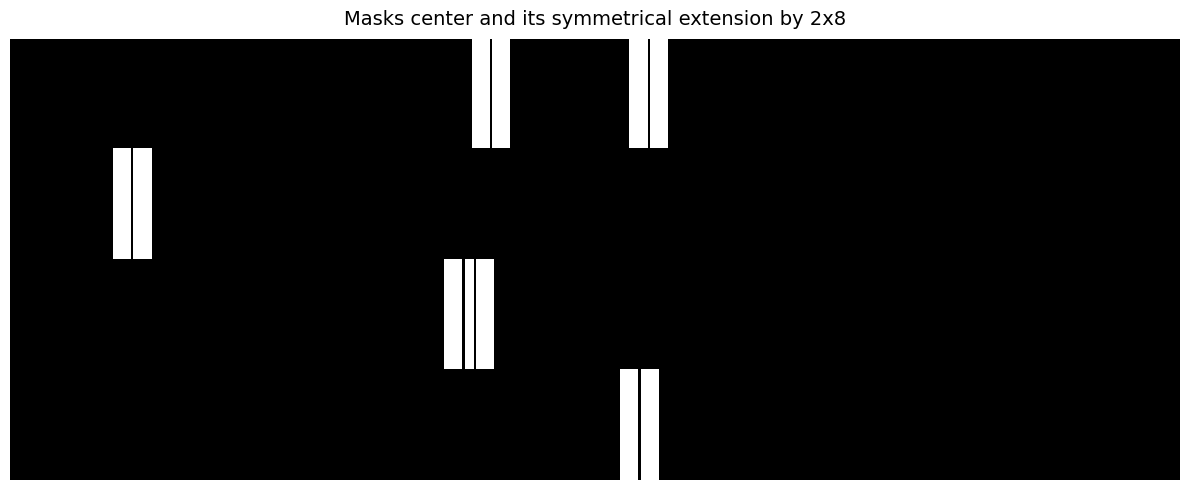

In [9]:
from utils.ZerosPolesDataset import positions_to_mask

halfwindow_list = [0, 8]

# Collect differences in a single loop
diff_masks = []

for key, positions in mask_dict.items():
    if key == 'zero_poles':
        continue
    mask = []
    for hw in halfwindow_list:
        mask.append(
            positions_to_mask(
                positions=positions,
                total_bits=configer['length'],
                halfwindow=hw
            )
        )

    diff = np.abs(np.array(mask[0], dtype=int) - np.array(mask[-1], dtype=int))
    diff_masks.append(diff)

plt.figure(figsize=(12, 5))
plt.imshow(diff_masks, cmap='gray', aspect='auto', interpolation='nearest')
plt.title(f'Masks center and its symmetrical extension by 2x{halfwindow_list[1]}', fontsize=14, pad=10)
plt.axis('off')
plt.tight_layout()
plt.show()

## Пример работы с dataloader

In [10]:
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [11]:
from utils.ZerosPolesDataset import ZerosPolesDataset, TransformsConfig

N_samples = 8
split = configer['split']

# Пути к маскам.
mask_path = Path(dataset_dir) / (split + "_masks.json")
assert mask_path.exists(), f"Mask not found: {mask_path}"
with open(mask_path, "r") as f:
    masks = json.load(f)

# Полный перечень ключей.    
samples_full = list(masks.keys())

# Случайная выборка данных.
samples = np.random.choice(samples_full, size=N_samples, replace=False).tolist()

### Визуализация выбранных данных

In [12]:
from utils.plot_functions import plot_responses

In [13]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 8,
    'fig_height_per_row': 2,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude',
            'xlabel': 'Frequency, Hz',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Phase',
            'xlabel': 'Frequency, Hz',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'ph'
        },
        {
            'ylabel': 'Diff 1 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_mag'
        },
        {
            'ylabel': 'Diff 1 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_ph'
        },
        {
            'ylabel': 'Diff 2 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_mag'
        },
        {
            'ylabel': 'Diff 2 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_ph'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

In [14]:
dataset = ZerosPolesDataset(
    dataset_dir=dataset_dir,
    split=configer['split'],
    mask_halfwindow=5,
    samples=samples
)


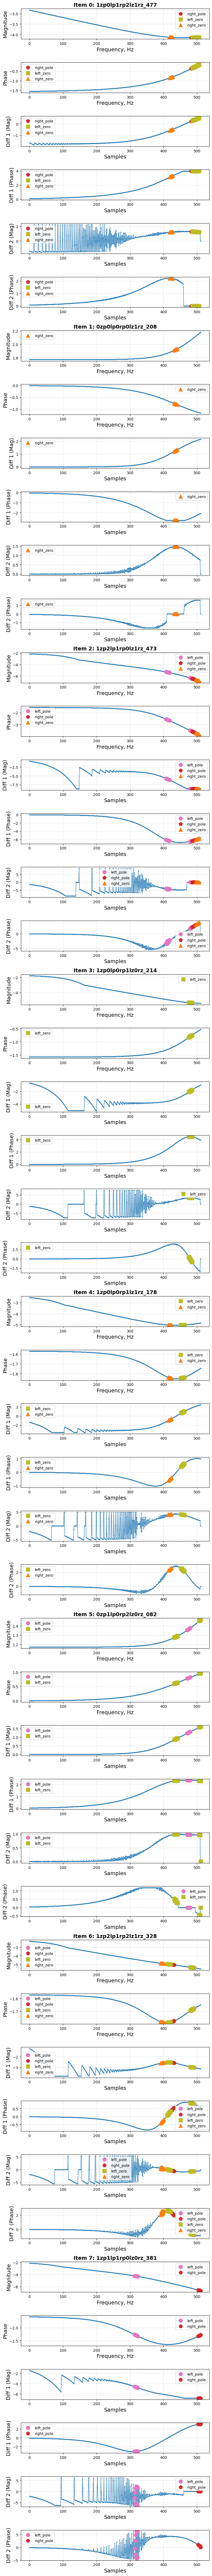

In [15]:
plot_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=8,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

In [16]:
from utils.plot_functions import plot_frequency_responses

Конфигуратор стиля графиков.

In [17]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 14,
    'fig_height_per_row': 4,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'mag_db'
        },
        {
            'ylabel': 'Gain (Real)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'real'
        },
        {
            'ylabel': 'Phase, deg',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph_deg'
        },
        {
            'ylabel': 'Gain (Imag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'imag'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

#### Нет аугментаций

ValueError: too many values to unpack (expected 3)

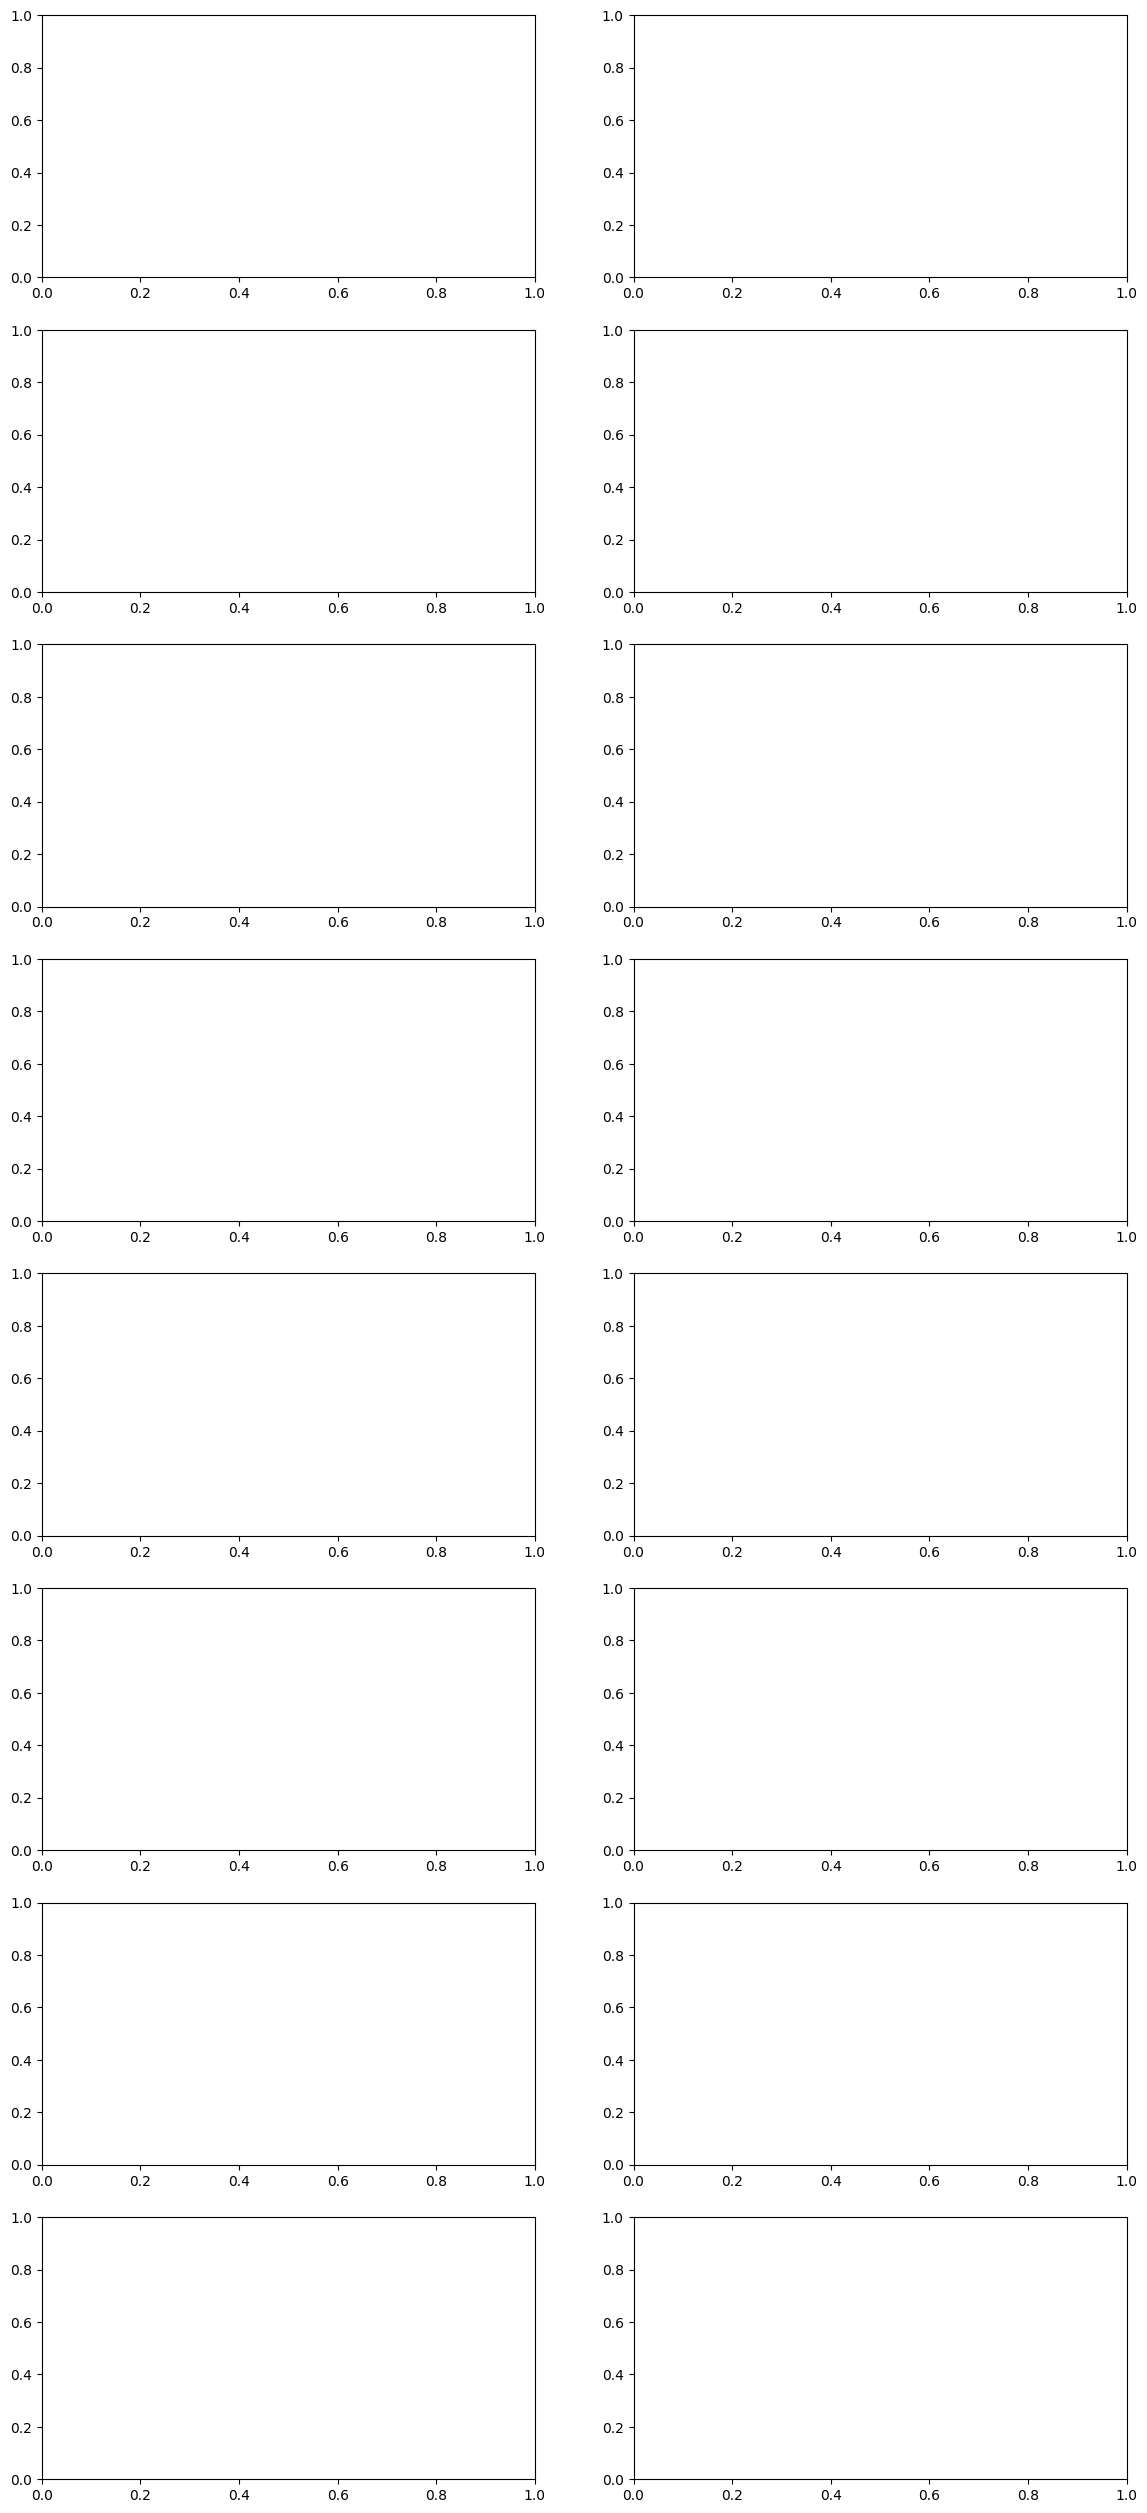

In [18]:
plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

### Визуализация выбранных данных: аугментации

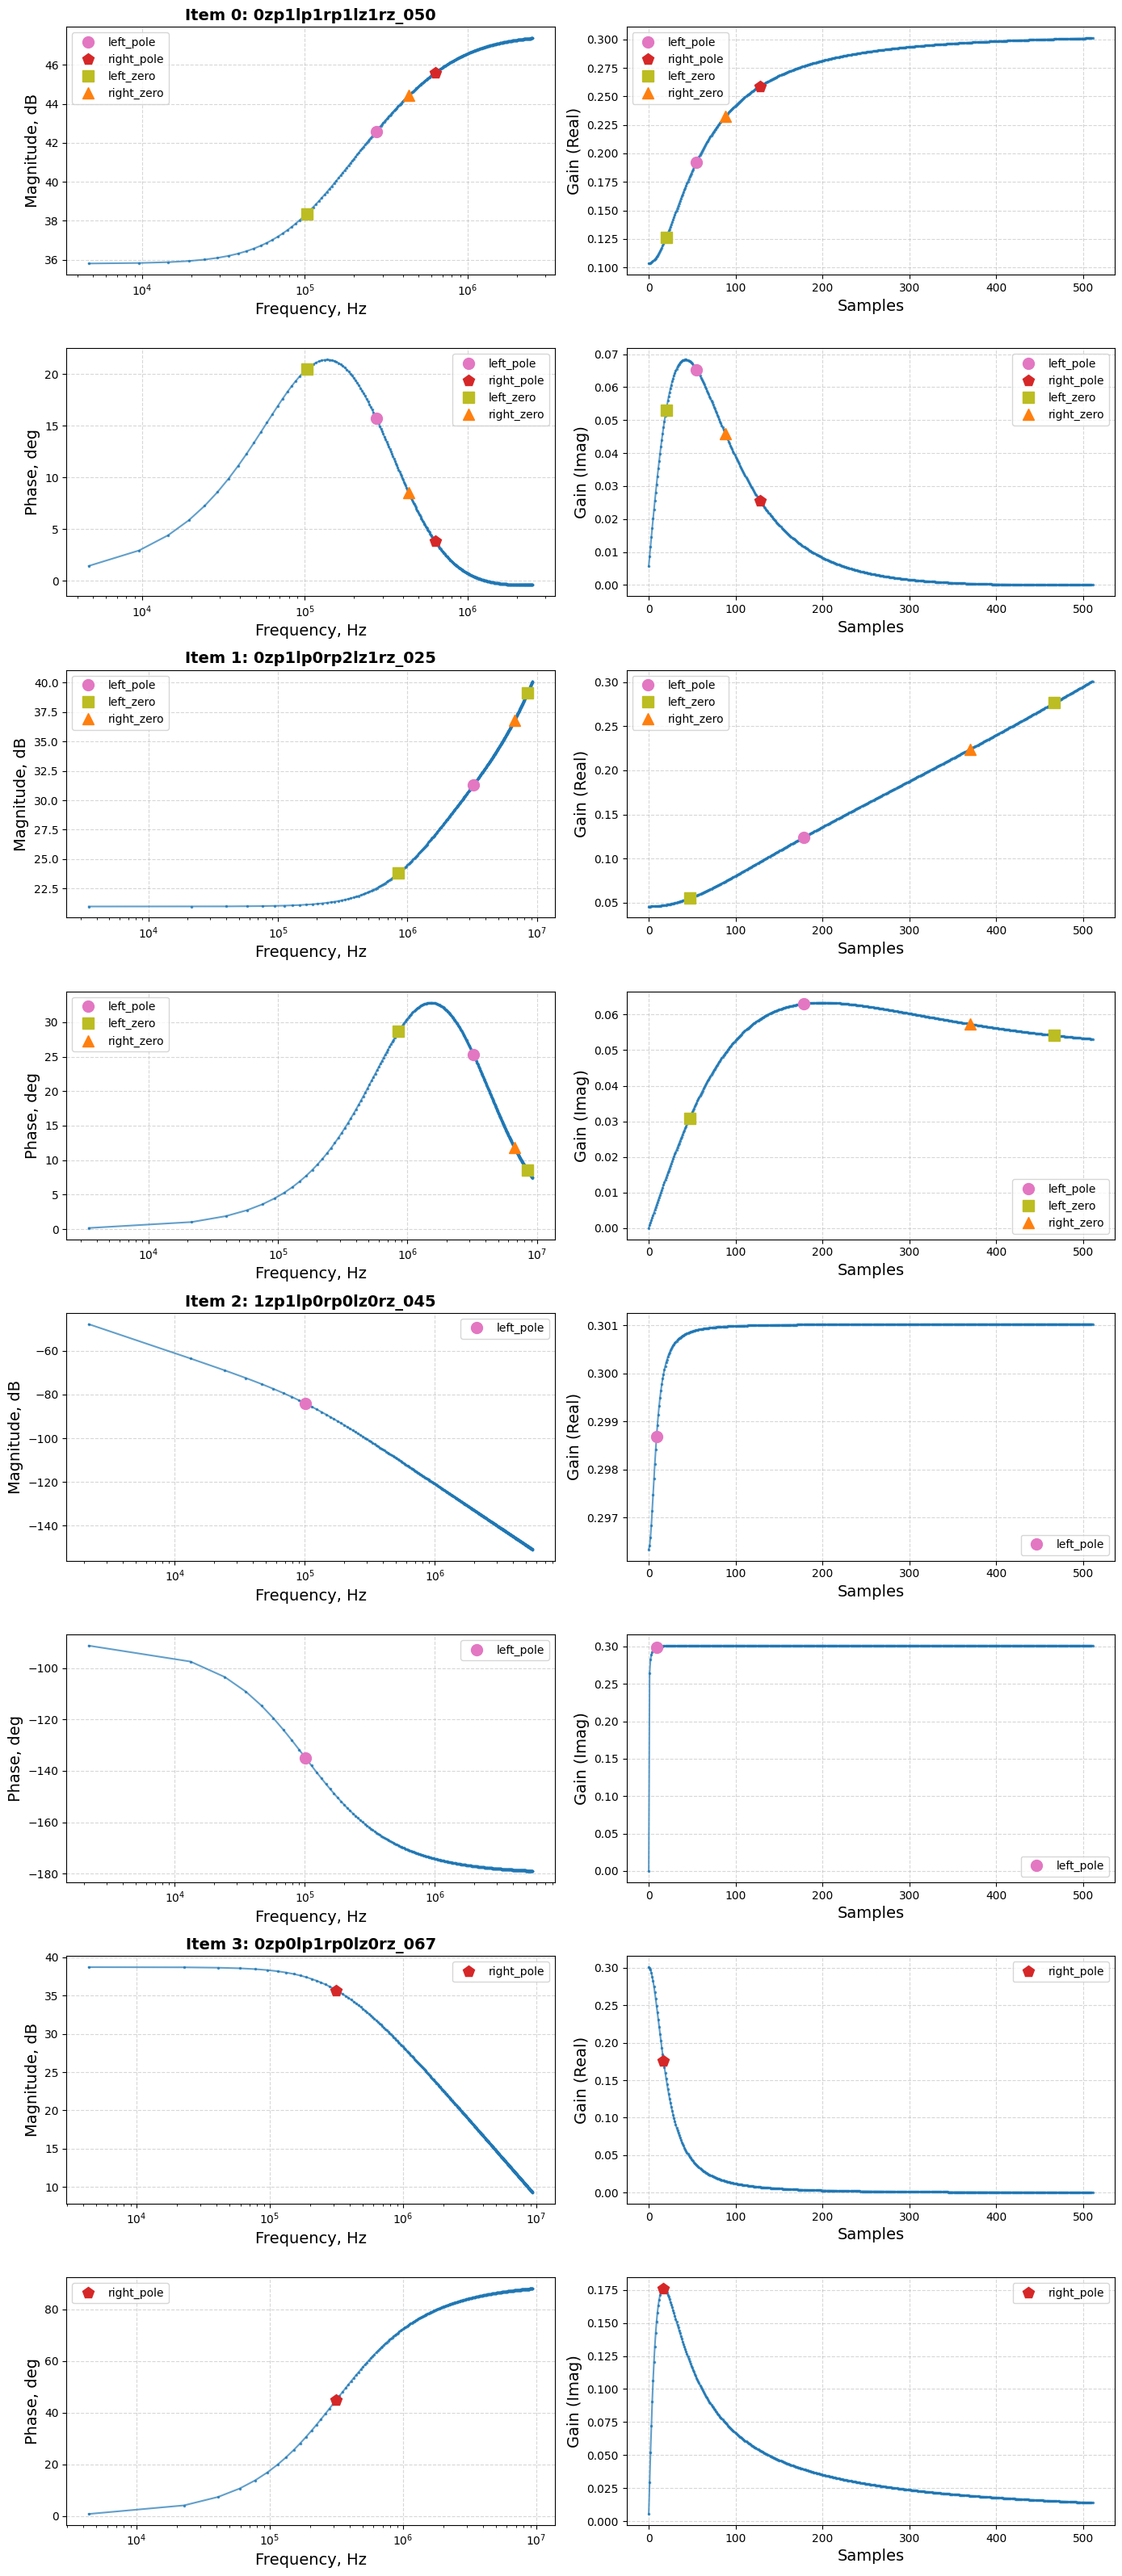

In [ ]:
custom_transforms = TransformsConfig(
    #crop_ratio=[1.0, 1.0],
    time_delay=[0.0, 1e-9],
    noise_level=[5e-3, 30e-3],
    noise_reduce=3,
    gain=[-1e3, 1e3]
)

dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples,
    #transforms=custom_transforms
)

plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/augmented_dataset_samples.png'))